In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

pd.set_option("display.max_columns", None)

df = pd.read_csv("heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [5]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'Cholesterol'] = np.nan
df_missing.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,6
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [8]:
print("Original shape: ", df.shape)
print("After removing some values: ", df_missing.shape)

Original shape:  (918, 12)
After removing some values:  (918, 12)


In [9]:
df_missing.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,NaN,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,NaN,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,NaN,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,NaN,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,NaN,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,NaN,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207.0,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284.0,0,Normal,120,N,0.0,Up,0


In [10]:
df_removed = df_missing.dropna()
df_removed.shape

(912, 12)

In [11]:
df_removed.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [12]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['Cholesterol'].fillna(df_imputed_mean['Cholesterol'].mean(), inplace=True)

df_imputed_mean.isna().sum()

/tmp/ipykernel_406/1193322841.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Cholesterol'].fillna(df_imputed_mean['Cholesterol'].mean(), inplace=True)


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [13]:
df_imputed_mean.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,198.462719,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,198.462719,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,198.462719,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,198.462719,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,198.462719,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,198.462719,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237.000000,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.000000,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207.000000,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284.000000,0,Normal,120,N,0.0,Up,0


In [14]:
df_imputed_median = df_missing.copy()
df_imputed_median['Cholesterol'].fillna(df_imputed_median['Cholesterol'].median(), inplace=True)

df_imputed_median.isna().sum()

/tmp/ipykernel_406/2620700675.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Cholesterol'].fillna(df_imputed_median['Cholesterol'].median(), inplace=True)


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [15]:
df_imputed_median.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,223.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,223.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,223.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,223.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,223.0,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,223.0,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208.0,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207.0,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284.0,0,Normal,120,N,0.0,Up,0


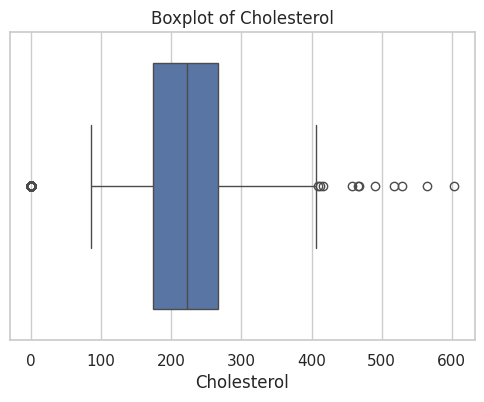

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Cholesterol'])
plt.title("Boxplot of Cholesterol")
plt.show()

In [17]:
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Cholesterol'] < lower) | (df['Cholesterol'] > upper)]
outliers.head(15)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1
250,44,M,ASY,135,491,0,Normal,135,N,0.0,Flat,1
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1


In [18]:
df_no_outliers = df[(df['Cholesterol'] >= lower) & (df['Cholesterol'] <= upper)]
print("Original shape: ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (918, 12)
After removing outliers:  (735, 12)


In [20]:
lower_cap = df['Cholesterol'].quantile(0.05)
upper_cap = df['Cholesterol'].quantile(0.95)

df_capped = df.copy()
df_capped['Cholesterol'] = df_capped['Cholesterol'].clip(lower_cap, upper_cap)

In [21]:
df[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']].head()

,Age,Cholesterol,MaxHR,RestingBP
0,40,289,172,140
1,49,180,156,160
2,37,283,98,130
3,48,214,108,138
4,54,195,122,150


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']].copy()

df_scaled[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Age,Cholesterol,MaxHR,RestingBP
0,0.244898,0.479270,0.788732,0.70
1,0.428571,0.298507,0.676056,0.80
2,0.183673,0.469320,0.267606,0.65
3,0.408163,0.354892,0.338028,0.69
4,0.530612,0.323383,0.436620,0.75


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']].copy()

df_standardized[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Age,Cholesterol,MaxHR,RestingBP
0,-1.433140,0.825070,1.382928,0.410909
1,-0.478484,-0.171961,0.754157,1.491752
2,-1.751359,0.770188,-1.525138,-0.129513
3,-0.584556,0.139040,-1.132156,0.302825
4,0.051881,-0.034755,-0.581981,0.951331


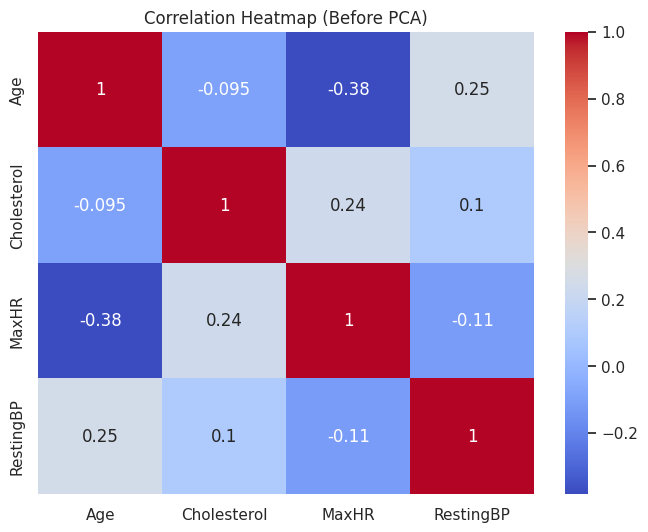

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_standardized[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [25]:
from sklearn.decomposition import PCA

X = df_standardized[['Age', 'Cholesterol', 'MaxHR', 'RestingBP']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.39134183 0.28470901]


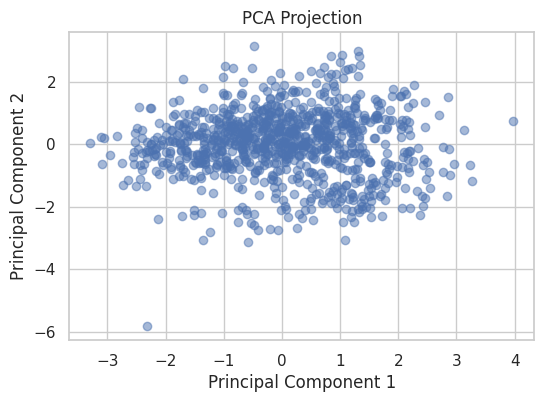

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()